This notebook trains Support Vector Regression (SVR) models to predict hourly taxi demand based on temporal, holiday and POI features. Two spatial granularities are compared to identify which performs better.

Steps:
1. Load pre-split datasets (census tract & community area)
2. Explore data and target distributions
3. Prepare features (auto-detect, target encoding)
4. Train three SVR variants (Linear, RBF, Polynomial) with grid search
5. Evaluate and compare both datasets
6. Visualize predictions and metrics

> <b>[NOTE]</b> Weather features (rain, heavy_rain, snow, wind, strong_wind, temperature_c, temperature_max_c, temperature_min_c) are included from the Dataset2 parquets.

## 0) Setup and configuration
All necessary packages are imported and the dataset paths are configured. The data is pre-split (train/test) and pre-scaled by the <i>03_data_preparation_for_nn_and_svm</i> notebook.

> <b>[NOTE]</b> H3 hexagonal cells were evaluated as a third spatial layer but are not used here: most hexagons contained zero or very few trips, i.e. extreme data sparsity, which would produce an unreliable model. The analysis that led to this decision is documented in the *Descriptive Analytics* notebook. Therefore only census tract and community area are compared below.

In [20]:
# imports
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import LinearSVR, SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    KFold, GridSearchCV,
)
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
)

In [21]:
# config: both datasets to compare
DATA_DIR = "../data/dataset2"
DATASETS = {
    "census_tract": {
        "train_path": f"{DATA_DIR}/03_census_tract_train.parquet",
        "test_path": f"{DATA_DIR}/03_census_tract_test.parquet",
        "spatial_col": "census_tract",
    },
    "community_area": {
        "train_path": f"{DATA_DIR}/03_community_area_train.parquet",
        "test_path": f"{DATA_DIR}/03_community_area_test.parquet",
        "spatial_col": "community_area",
    },
}

# 1) Data loading and exploration
Both datasets are loaded separately (train + test). The census tract dataset has significantly fewer records as approximately half of the census tracts were dropped during data cleaning due to missing values. We can also see that not all census tracts appear in the test set, while the community area dataset covers all 77 areas in both splits.

In [22]:
# load both datasets (train + test separately) and show overview
raw_data = {}
for name, cfg in DATASETS.items():
    train_df = pl.read_parquet(cfg["train_path"])
    test_df = pl.read_parquet(cfg["test_path"])
    raw_data[name] = {"train": train_df, "test": test_df}
    spatial = cfg["spatial_col"]
    print(f"=== {name} ===")
    print(f"  Train:       {train_df.shape}")
    print(f"  Test:        {test_df.shape}")
    print(f"  Columns:     {train_df.columns}")
    print(f"  Unique {spatial} (train): {train_df[spatial].n_unique():,}")
    print(f"  Unique {spatial} (test):  {test_df[spatial].n_unique():,}")
    print(f"  trip_count (train): mean={train_df['trip_count'].mean():.2f}  "
          f"median={train_df['trip_count'].median():.1f}  max={train_df['trip_count'].max()}")
    print(f"  trip_count (test):  mean={test_df['trip_count'].mean():.2f}  "
          f"median={test_df['trip_count'].median():.1f}  max={test_df['trip_count'].max()}")
    nulls_train = sum(train_df.null_count().row(0))
    nulls_test = sum(test_df.null_count().row(0))
    print(f"  Nulls: train={nulls_train}  test={nulls_test}")
    print()

=== census_tract ===
  Train:       (309880, 32)
  Test:        (77469, 32)
  Columns:     ['census_tract', 'trip_count', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'DayOfWeek_Friday', 'DayOfWeek_Saturday', 'DayOfWeek_Sunday', 'DayOfWeek_Thursday', 'DayOfWeek_Tuesday', 'DayOfWeek_Wednesday', 'BankHoliday', 'CorporateHoliday', 'CityHoliday', 'StateHoliday', 'rain', 'heavy_rain', 'snow', 'wind', 'strong_wind', 'temperature_c', 'temperature_max_c', 'temperature_min_c', 'healthcare', 'education', 'amenity', 'leisure', 'shops', 'public_services', 'tourism', 'nature']
  Unique census_tract (train): 458
  Unique census_tract (test):  305
  trip_count (train): mean=16.01  median=6.0  max=532
  trip_count (test):  mean=14.63  median=6.0  max=235
  Nulls: train=0  test=0

=== community_area ===
  Train:       (705443, 32)
  Test:        (176360, 32)
  Columns:     ['community_area', 'trip_count', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'DayOfWeek_Friday', 'DayOfWeek_Saturday', '

## 1.1) Target distribution
The `trip_count` distribution is right-skewed with a long tail, which is typical for demand data. Most hours have low trip counts while a few hours have very high demand.

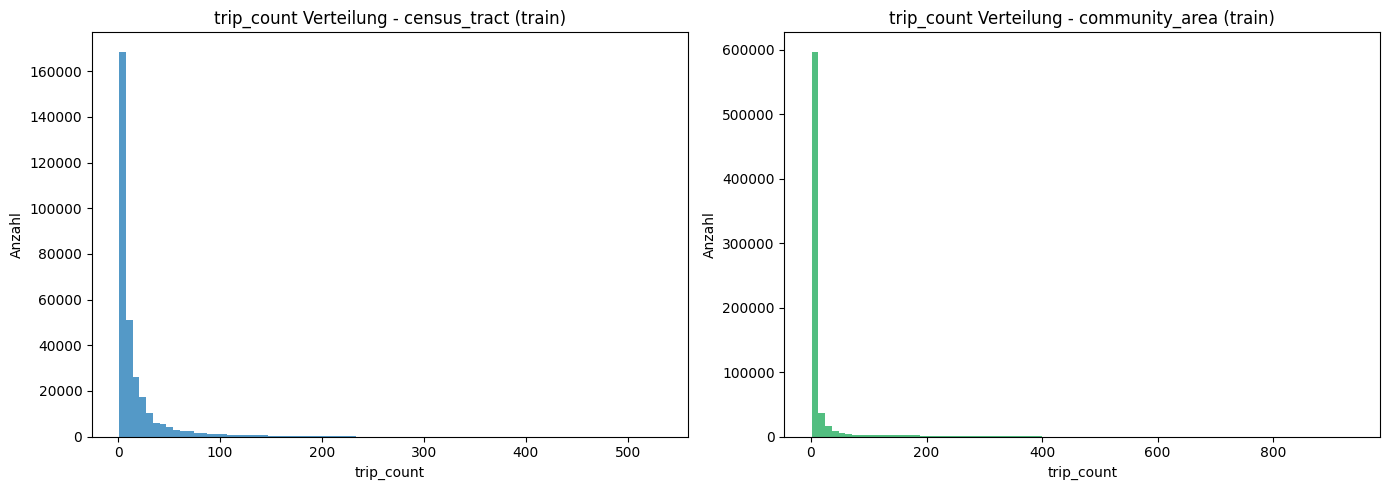

In [23]:
# compare trip_count distributions side by side (train data)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"census_tract": "#2980b9", "community_area": "#27ae60"}
for ax, (name, data) in zip(axes, raw_data.items()):
    ax.hist(data["train"]["trip_count"].to_numpy(), bins=80, color=colors[name], alpha=0.8)
    ax.set_title(f"trip_count Verteilung - {name} (train)")
    ax.set_xlabel("trip_count")
    ax.set_ylabel("Anzahl")
plt.tight_layout()
plt.show()

# 2) Feature preparation
Numeric features are auto-detected from both datasets. Boolean columns are cast to `Int64`. The spatial ID (`census_tract` or `community_area`) and the target `trip_count` are excluded from features.

A target encoding is applied: the mean `trip_count` per spatial unit is calculated on the training set only and joined back to both train and test. Unseen spatial units in the test set fall back to the global mean. This way the model receives information about the general demand level of each area without leaking test data.

> <b>[NOTE]</b> The pre-scaled data from notebook 03 contains <i>NaN</i> values in some POI columns (caused by <i>std=0</i> during scaling). These are filled with `0.0`, which is equivalent to the mean for standardized data.

In [24]:
# helper: prepare pre-split data for SVR (target encoding + numpy extraction)
NUMERIC_DTYPES = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64,
}

# fixed weather column names (do not infer heuristically)
WEATHER_COLS = [
    "rain", "heavy_rain", "snow", "wind", "strong_wind",
    "temperature_c", "temperature_max_c", "temperature_min_c",
]

def prepare_dataset(train_df, test_df, spatial_col, use_weather=True, log_target=False):
    """Target encoding (train only) + numpy arrays for pre-split, pre-scaled data."""
    # cast Boolean columns to Int64 so they work as numeric features
    bool_cols = [c for c in train_df.columns if train_df.schema[c] == pl.Boolean]
    if bool_cols:
        train_df = train_df.with_columns([pl.col(c).cast(pl.Int64) for c in bool_cols])
        test_df = test_df.with_columns([pl.col(c).cast(pl.Int64) for c in bool_cols])

    # auto-detect numeric feature columns (exclude spatial ID and target)
    exclude = {spatial_col, "trip_count"}
    feature_cols = [
        c for c in train_df.columns
        if c not in exclude and train_df.schema[c] in NUMERIC_DTYPES
    ]
    # optionally drop weather columns (ablation)
    if not use_weather:
        feature_cols = [c for c in feature_cols if c not in WEATHER_COLS]

    # fill NaN values (Polars NaN != null; caused by std=0 during scaling)
    for col in feature_cols:
        if train_df.schema[col] in (pl.Float32, pl.Float64):
            train_df = train_df.with_columns(pl.col(col).fill_nan(0.0))
            test_df = test_df.with_columns(pl.col(col).fill_nan(0.0))

    # target encoding: mean trip_count per spatial unit (train only)
    spatial_mean = (
        train_df.group_by(spatial_col)
        .agg(pl.col("trip_count").mean().alias("spatial_target_mean"))
    )
    global_mean = train_df["trip_count"].mean()
    train_df = train_df.join(spatial_mean, on=spatial_col, how="left").with_columns(
        pl.col("spatial_target_mean").fill_null(global_mean)
    )
    test_df = test_df.join(spatial_mean, on=spatial_col, how="left").with_columns(
        pl.col("spatial_target_mean").fill_null(global_mean)
    )

    feature_cols_final = feature_cols + ["spatial_target_mean"]

    X_train = train_df.select(feature_cols_final).to_numpy()
    y_train = train_df["trip_count"].to_numpy().astype(float)
    X_test = test_df.select(feature_cols_final).to_numpy()
    y_test = test_df["trip_count"].to_numpy().astype(float)

    # optional log1p target transform (train only; test stays in original scale)
    if log_target:
        y_train = np.log1p(y_train)

    return {
        "X_train": X_train, "y_train": y_train,
        "X_test": X_test, "y_test": y_test,
        "feature_cols": feature_cols_final,
        "n_features": len(feature_cols_final),
        "n_spatial": train_df[spatial_col].n_unique(),
        "log_target": log_target,
    }

## Validation strategy
The train/test split was done **chronologically** in notebook 03: the records are ordered by timestamp and the most recent 20 % form the test set (~80 / 20 by time). This is essential for an honest demand-forecasting evaluation.

A random split would mix past and future observations and effectively turn the task into **temporal interpolation** rather than genuine *future* prediction - neighbouring rows would share the same weather/day-of-week constellation and the model could "cheat" instead of learning to extrapolate forward in time. The chronological split guarantees that the model is always evaluated on a later time period than it was trained on.

# 3) Model training
Three SVR variants are trained with grid search and 5-fold cross-validation:
- <b>LinearSVR</b>: fast linear baseline
- <b>RBF kernel</b>: captures non-linear relationships
- <b>Polynomial kernel</b>: flexible non-linear alternative

> <b>[NOTE]</b> Hyperparameter search uses `HalvingGridSearchCV` (Successive
> Halving) instead of an exhaustive `GridSearchCV`. The full parameter grid
> is still evaluated, but candidates compete on increasing subsets of the
> training sample: weak parameter combinations are eliminated early and only
> promising ones are refit on more data. This gives the same best-params
> result as a full grid search at a fraction of the runtime.

The best model is selected by the lowest cross-validated RMSE, then refit on the full training set and evaluated on the test set. A `StandardScaler` is kept inside the pipeline to scale the `spatial_target_mean` feature, which is the only unscaled input.

> <b>[NOTE]</b> Grid search uses a random subsample of 100,000 rows for efficiency. The final model is refit on a subsample of 50,000 rows (`REFIT_SAMPLE_SIZE`). Kernel SVR scales O(n²) in training samples, making a full refit on 300k+ rows computationally infeasible.

In [25]:
# helper: run 3 SVR models (Linear, RBF, Poly) with grid search,
# pick the best by CV RMSE, refit on full train, evaluate on test
GRID_SAMPLE_SIZE = 20000
REFIT_SAMPLE_SIZE = 50_000  # kernel SVR scales O(n^2); full refit on 300k+ rows infeasible

def run_svr_pipeline(data, dataset_name):
    X_train, y_train = data["X_train"], data["y_train"]
    X_test, y_test = data["X_test"], data["y_test"]

    # subsample for grid search
    np.random.seed(7)
    if len(X_train) > GRID_SAMPLE_SIZE:
        idx = np.random.choice(len(X_train), size=GRID_SAMPLE_SIZE, replace=False)
        X_sub, y_sub = X_train[idx], y_train[idx]
    else:
        X_sub, y_sub = X_train, y_train
    print(f"  Grid Search Sample: {X_sub.shape[0]:,} Zeilen ({data['n_features']} Features)")

    cv = KFold(n_splits=5, shuffle=True, random_state=7)

    # model configs: (name, pipeline, param_grid)
    configs = [
        ("LinearSVR",
         Pipeline([("scaler", StandardScaler()),
                   ("svr", LinearSVR(dual="auto", max_iter=10000, random_state=7))]),
         {"svr__C": [0.01, 0.1, 1, 10], "svr__epsilon": [0.1, 1, 10]}),
        ("RBF",
         Pipeline([("scaler", StandardScaler()),
                   # cache_size=2000 (MB) reduces redundant kernel evaluations during
                   # libsvm training. same result, faster fits
                   ("svr", SVR(kernel="rbf", max_iter=50_000, cache_size=2000))]),  # safety cap; prevents non-convergence on large samples
         {"svr__C": [0.1, 1, 10],
          "svr__gamma": ["scale", 0.01, 0.1, 1],
          "svr__epsilon": [0.1, 1, 10]}),
        ("Poly",
         Pipeline([("scaler", StandardScaler()),
                   ("svr", SVR(kernel="poly", max_iter=50_000, cache_size=2000))]),  # safety cap; prevents non-convergence on large samples
         {"svr__C": [0.1, 1, 10],
          "svr__degree": [2, 3],
          "svr__coef0": [0, 1],
          "svr__epsilon": [0.1, 1, 10]}),
    ]

    model_results = {}
    for model_name, pipe, grid in configs:
        print(f"  [{dataset_name}] {model_name} ...")
        gs = HalvingGridSearchCV(pipe, grid, cv=cv,
                                 scoring="neg_mean_squared_error",
                                 factor=3, resource="n_samples",
                                 min_resources="exhaust",
                                 n_jobs=-1, verbose=1, random_state=7)
        gs.fit(X_sub, y_sub)
        cv_rmse = np.sqrt(-gs.best_score_)
        model_results[model_name] = {
            "cv_rmse": cv_rmse,
            "params": gs.best_params_,
            "estimator": gs.best_estimator_,
        }
        print(f"    CV RMSE: {cv_rmse:.4f}  Params: {gs.best_params_}")

    # select best model by CV RMSE (lowest = best)
    best_name = min(model_results, key=lambda k: model_results[k]["cv_rmse"])
    best_model = model_results[best_name]["estimator"]
    if len(X_train) > REFIT_SAMPLE_SIZE:
        np.random.seed(7)
        refit_idx = np.random.choice(len(X_train), size=REFIT_SAMPLE_SIZE, replace=False)
        X_refit, y_refit = X_train[refit_idx], y_train[refit_idx]
    else:
        X_refit, y_refit = X_train, y_train
    print(f"  Refit: {len(X_refit):,} rows (of {len(X_train):,})")
    best_model.fit(X_refit, y_refit)
    y_pred = best_model.predict(X_test)
    # if trained on log1p target, transform predictions back to original scale
    # (metrics are always computed against the untransformed y_test)
    if data.get("log_target"):
        y_pred = np.expm1(y_pred)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # MAPE only on rows with actual > 0
    mask = y_test > 0
    mape = (np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100
            if mask.sum() > 0 else float("nan"))

    print(f"\n  [{dataset_name}] Bestes Modell: {best_name}")
    print(f"    Test MAE:  {mae:.4f}")
    print(f"    Test RMSE: {rmse:.4f}")
    print(f"    Test R2:   {r2:.4f}")
    print(f"    Test MAPE: {mape:.2f}%")

    return {
        "best_model": best_name,
        "best_params": model_results[best_name]["params"],
        "cv_rmse": model_results[best_name]["cv_rmse"],
        "test_mae": mae,
        "test_rmse": rmse,
        "test_r2": r2,
        "test_mape": mape,
        "y_pred": y_pred,
        "y_test": y_test,
        "all_cv_rmse": {k: v["cv_rmse"] for k, v in model_results.items()},
    }

## 3.1) Run pipeline on both datasets
The full pipeline is executed for both census tract and community area datasets. Each dataset goes through feature preparation, grid search and evaluation independently.

In [26]:
# quick speed test: 1 fit per model to estimate total runtime
import time

# prepare census_tract if not done yet
prepared = {}
if "census_tract" not in prepared:
    prepared["census_tract"] = prepare_dataset(
        raw_data["census_tract"]["train"], raw_data["census_tract"]["test"], "census_tract"
    )

# same subsample logic as grid search (one CV fold = 80% of subsample)
np.random.seed(7)
X_full = prepared["census_tract"]["X_train"]
y_full = prepared["census_tract"]["y_train"]
if len(X_full) > GRID_SAMPLE_SIZE:
    idx = np.random.choice(len(X_full), size=GRID_SAMPLE_SIZE, replace=False)
    X_sub, y_sub = X_full[idx], y_full[idx]
else:
    X_sub, y_sub = X_full, y_full
n_fold = int(len(X_sub) * 0.8)
X_fold, y_fold = X_sub[:n_fold], y_sub[:n_fold]

bench_models = [
    ("LinearSVR", Pipeline([("scaler", StandardScaler()),
                             ("svr", LinearSVR(C=1, dual="auto", max_iter=10000, random_state=7))])),
    ("RBF", Pipeline([("scaler", StandardScaler()),
                      ("svr", SVR(kernel="rbf", C=1, gamma="scale"))])),
    ("Poly", Pipeline([("scaler", StandardScaler()),
                       ("svr", SVR(kernel="poly", C=1, degree=2, coef0=0))])),
]
grid_fits = {"LinearSVR": 60, "RBF": 180, "Poly": 180}

print(f"Speed test: 1 fit per model on {n_fold:,} rows (one CV fold)")
print(f"GRID_SAMPLE_SIZE = {GRID_SAMPLE_SIZE:,}\n")
total_est = 0
for name, pipe in bench_models:
    t0 = time.time()
    pipe.fit(X_fold, y_fold)
    elapsed = time.time() - t0
    model_total = elapsed * grid_fits[name]
    total_est += model_total
    print(f"  {name:12s}  {elapsed:6.1f}s/Fit  ->  {grid_fits[name]} Fits = ~{model_total/60:.0f} Min/Dataset")
print(f"\n  Geschaetzte Gesamtzeit (2 Datasets): ~{total_est*2/60:.0f} Min")

# refit timing: final model fits on REFIT_SAMPLE_SIZE rows (not the full train)
np.random.seed(7)
n_refit = min(REFIT_SAMPLE_SIZE, len(X_full))
refit_idx = np.random.choice(len(X_full), size=n_refit, replace=False)
X_refit_bench, y_refit_bench = X_full[refit_idx], y_full[refit_idx]

print(f"Refit test: 1 fit per model on {n_refit:,} rows (REFIT_SAMPLE_SIZE)")
refit_total = 0
for name, pipe in bench_models:
    t0 = time.time()
    pipe.fit(X_refit_bench, y_refit_bench)
    elapsed = time.time() - t0
    refit_total += elapsed
    print(f"  {name:12s}  {elapsed:6.1f}s/Fit")
print(f"\n  Geschaetzte Refit-Zeit (pro Dataset): ~{refit_total/60:.0f} Min")


Speed test: 1 fit per model on 16,000 rows (one CV fold)
GRID_SAMPLE_SIZE = 20,000

  LinearSVR        0.2s/Fit  ->  60 Fits = ~0 Min/Dataset
  RBF             10.1s/Fit  ->  180 Fits = ~30 Min/Dataset
  Poly             7.7s/Fit  ->  180 Fits = ~23 Min/Dataset

  Geschaetzte Gesamtzeit (2 Datasets): ~108 Min
Refit test: 1 fit per model on 50,000 rows (REFIT_SAMPLE_SIZE)
  LinearSVR        2.5s/Fit
  RBF            109.0s/Fit
  Poly           132.2s/Fit

  Geschaetzte Refit-Zeit (pro Dataset): ~4 Min


In [27]:
# run full pipeline on both datasets
all_results = {}
prepared = {}
for name, cfg in DATASETS.items():
    print(f"\n{'='*60}")
    print(f"DATASET: {name}")
    print(f"{'='*60}")

    prepared[name] = prepare_dataset(
        raw_data[name]["train"], raw_data[name]["test"], cfg["spatial_col"]
    )
    p = prepared[name]
    print(f"  Features: {p['n_features']}  |  Unique spatial: {p['n_spatial']:,}")
    print(f"  Train: {p['X_train'].shape[0]:,}  |  Test: {p['X_test'].shape[0]:,}")
    print(f"  Feature columns: {p['feature_cols']}")

    all_results[name] = run_svr_pipeline(prepared[name], name)


DATASET: census_tract
  Features: 31  |  Unique spatial: 458
  Train: 309,880  |  Test: 77,469
  Feature columns: ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'DayOfWeek_Friday', 'DayOfWeek_Saturday', 'DayOfWeek_Sunday', 'DayOfWeek_Thursday', 'DayOfWeek_Tuesday', 'DayOfWeek_Wednesday', 'BankHoliday', 'CorporateHoliday', 'CityHoliday', 'StateHoliday', 'rain', 'heavy_rain', 'snow', 'wind', 'strong_wind', 'temperature_c', 'temperature_max_c', 'temperature_min_c', 'healthcare', 'education', 'amenity', 'leisure', 'shops', 'public_services', 'tourism', 'nature', 'spatial_target_mean']
  Grid Search Sample: 20,000 Zeilen (31 Features)
  [census_tract] LinearSVR ...
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 2222
max_resources_: 20000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 12
n_resources: 2222
Fitting 5 folds for each of 12 candidates, totalling 60 fits
----------
iter: 1
n_candidates: 4
n_resources: 6666
Fitting 5

c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    CV RMSE: 13.8728  Params: {'svr__C': 10, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 10}
  Refit: 50,000 rows (of 309,880)


c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



  [census_tract] Bestes Modell: Poly
    Test MAE:  7.4312
    Test RMSE: 12.9951
    Test R2:   0.6656
    Test MAPE: 129.14%

DATASET: community_area
  Features: 31  |  Unique spatial: 77
  Train: 705,443  |  Test: 176,360
  Feature columns: ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'DayOfWeek_Friday', 'DayOfWeek_Saturday', 'DayOfWeek_Sunday', 'DayOfWeek_Thursday', 'DayOfWeek_Tuesday', 'DayOfWeek_Wednesday', 'BankHoliday', 'CorporateHoliday', 'CityHoliday', 'StateHoliday', 'rain', 'heavy_rain', 'snow', 'wind', 'strong_wind', 'temperature_c', 'temperature_max_c', 'temperature_min_c', 'healthcare', 'education', 'amenity', 'leisure', 'shops', 'public_services', 'tourism', 'nature', 'spatial_target_mean']
  Grid Search Sample: 20,000 Zeilen (31 Features)
  [community_area] LinearSVR ...
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 2222
max_resources_: 20000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 12
n_resourc

c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    CV RMSE: 16.3298  Params: {'svr__C': 10, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 1}
  Refit: 50,000 rows (of 705,443)


c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



  [community_area] Bestes Modell: Poly
    Test MAE:  6.2632
    Test RMSE: 20.2022
    Test R2:   0.8290
    Test MAPE: 76.84%


# 4) Results
Below table compares the best model for each dataset across multiple metrics. The per-model breakdown shows the cross-validated RMSE for all three SVR variants, allowing us to assess which kernel and which spatial granularity performs best.

In [28]:
# comparison table
rows = []
for name, res in all_results.items():
    rows.append({
        "Dataset": name,
        "Best Model": res["best_model"],
        "Features": prepared[name]["n_features"],
        "CV RMSE": round(res["cv_rmse"], 4),
        "Test MAE": round(res["test_mae"], 4),
        "Test RMSE": round(res["test_rmse"], 4),
        "Test R2": round(res["test_r2"], 4),
        "Test MAPE": round(res["test_mape"], 2),
    })
comparison = pl.DataFrame(rows)
display(comparison)

# per-dataset breakdown of all 3 models
print("\nCV RMSE pro Modell:")
for name, res in all_results.items():
    for model, rmse in res["all_cv_rmse"].items():
        marker = " <-- BEST" if model == res["best_model"] else ""
        print(f"  {name:16s} {model:12s} {rmse:.4f}{marker}")

Dataset,Best Model,Features,CV RMSE,Test MAE,Test RMSE,Test R2,Test MAPE
str,str,i64,f64,f64,f64,f64,f64
"""census_tract""","""Poly""",31,13.8728,7.4312,12.9951,0.6656,129.14
"""community_area""","""Poly""",31,16.3298,6.2632,20.2022,0.829,76.84



CV RMSE pro Modell:
  census_tract     LinearSVR    19.3399
  census_tract     RBF          14.9031
  census_tract     Poly         13.8728 <-- BEST
  community_area   LinearSVR    27.9548
  community_area   RBF          20.7011
  community_area   Poly         16.3298 <-- BEST


# 5) Visualization
## 5.1) Predicted vs Actual
Scatter plots compare predicted against actual `trip_count` values for each dataset. The red dashed line represents a perfect prediction. Points below the line indicate underestimation, points above indicate overestimation.

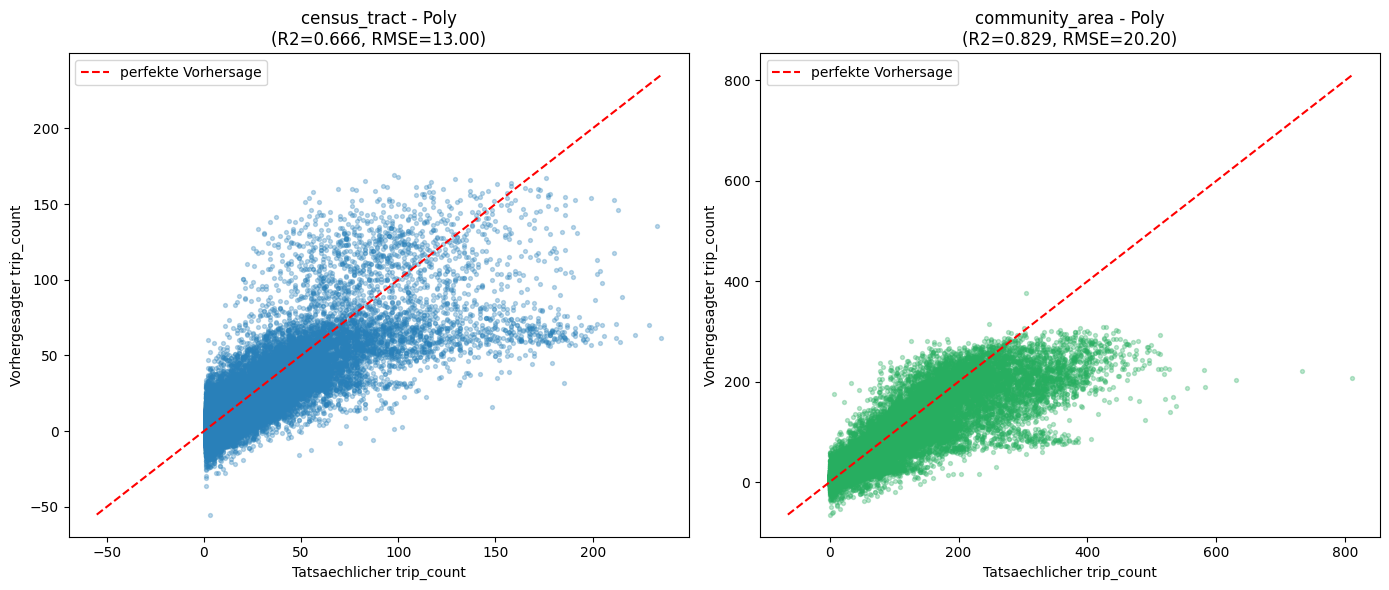

In [29]:
# comparison plots: predicted vs actual for each dataset
n = len(all_results)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 6), squeeze=False)
colors = {"census_tract": "#2980b9", "community_area": "#27ae60"}

for ax, (name, res) in zip(axes[0], all_results.items()):
    y_t, y_p = res["y_test"], res["y_pred"]
    ax.scatter(y_t, y_p, s=8, alpha=0.3, color=colors.get(name, "#2980b9"))
    lims = [min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="perfekte Vorhersage")
    ax.set_xlabel("Tatsaechlicher trip_count")
    ax.set_ylabel("Vorhergesagter trip_count")
    ax.set_title(f"{name} - {res['best_model']}\n(R2={res['test_r2']:.3f}, RMSE={res['test_rmse']:.2f})")
    ax.legend()

plt.tight_layout()
plt.show()

## 5.2) Metric comparison
The bar charts below compare the test metrics side by side. Lower MAE and RMSE indicate better predictions, while higher R2 indicates a better fit.

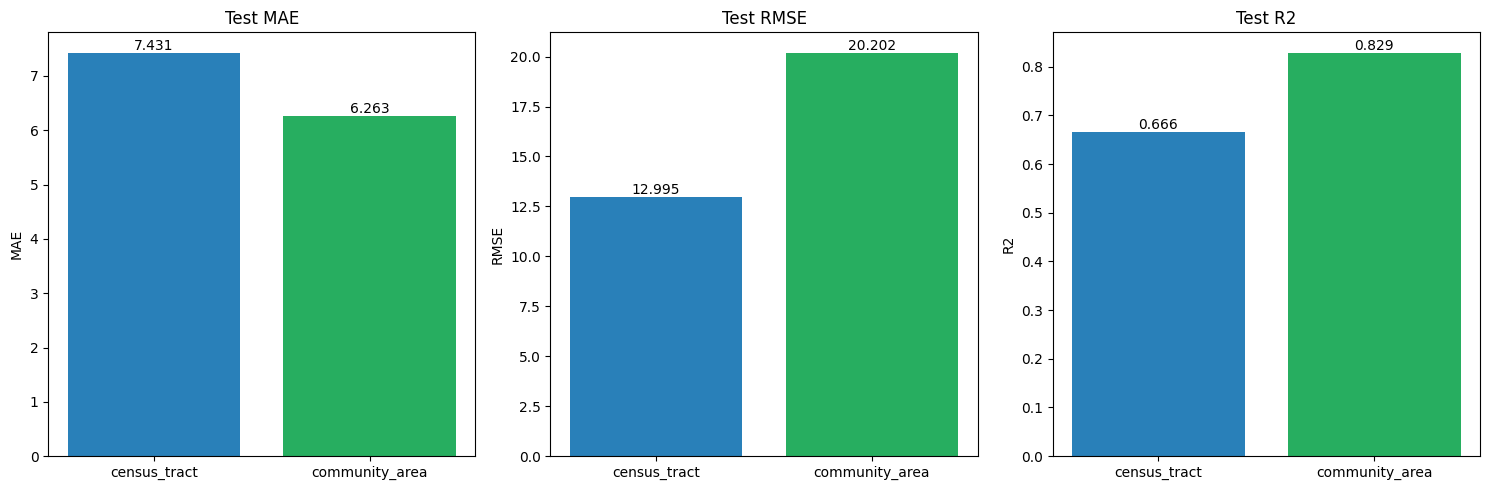

In [30]:
# comparison bar chart: test metrics side by side
metrics = ["test_mae", "test_rmse", "test_r2"]
metric_labels = ["MAE", "RMSE", "R2"]
dataset_names = list(all_results.keys())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric, label in zip(axes, metrics, metric_labels):
    vals = [all_results[n][metric] for n in dataset_names]
    bars = ax.bar(dataset_names, vals, color=[colors.get(n, "#2980b9") for n in dataset_names])
    ax.set_title(f"Test {label}")
    ax.set_ylabel(label)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{v:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

# Ablation: Weather & log-Target
To quantify the individual contribution of the weather features and of a log-transformed target, three model variants are compared under identical conditions:

- <b>(a) without weather</b>: weather columns removed from the feature set.
- <b>(b) with weather</b>: full feature set including the eight weather columns.
- <b>(c) weather + log1p</b>: full features plus a `log1p` transform of the training target.

All three variants use the same grid search (`GRID_SAMPLE_SIZE`) and the same refit (`REFIT_SAMPLE_SIZE`), so any metric difference is attributable solely to the feature / target change.

> <b>[NOTE]</b> `log1p` compresses the strong right skew of `trip_count`. The model is trained on the transformed target, but predictions are mapped back to the original scale with `expm1`, and all metrics (MAE / RMSE / R2 / MAPE) are computed against the untransformed `y_test` so that every variant remains directly comparable.

In [31]:
# Ablation study: 2 datasets x 3 variants = 6 runs (~15-20 min total)
VARIANTS = [
    ("ohne Wetter",    dict(use_weather=False, log_target=False)),
    ("mit Wetter",     dict(use_weather=True,  log_target=False)),
    ("Wetter + log1p", dict(use_weather=True,  log_target=True)),
]

ablation_rows = []
for ds_name, ds_cfg in DATASETS.items():
    for var_name, kwargs in VARIANTS:
        print(f"\n{'='*60}")
        print(f"ABLATION: {ds_name} | {var_name}")
        print(f"{'='*60}")
        data = prepare_dataset(
            raw_data[ds_name]["train"], raw_data[ds_name]["test"],
            ds_cfg["spatial_col"], **kwargs,
        )
        print(f"  Features: {data['n_features']}  |  log_target: {data['log_target']}")
        res = run_svr_pipeline(data, f"{ds_name} | {var_name}")
        ablation_rows.append({
            "Dataset": ds_name,
            "Variante": var_name,
            "Best Model": res["best_model"],
            "Test R2": round(res["test_r2"], 4),
            "Test RMSE": round(res["test_rmse"], 4),
            "Test MAE": round(res["test_mae"], 4),
            "Test MAPE": round(res["test_mape"], 2),
        })

ablation = pl.DataFrame(ablation_rows).sort(["Dataset", "Variante"])
display(ablation)


ABLATION: census_tract | ohne Wetter
  Features: 23  |  log_target: False
  Grid Search Sample: 20,000 Zeilen (23 Features)
  [census_tract | ohne Wetter] LinearSVR ...
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 2222
max_resources_: 20000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 12
n_resources: 2222
Fitting 5 folds for each of 12 candidates, totalling 60 fits
----------
iter: 1
n_candidates: 4
n_resources: 6666
Fitting 5 folds for each of 4 candidates, totalling 20 fits
----------
iter: 2
n_candidates: 2
n_resources: 19998
Fitting 5 folds for each of 2 candidates, totalling 10 fits
    CV RMSE: 19.3402  Params: {'svr__C': 10, 'svr__epsilon': 10}
  [census_tract | ohne Wetter] RBF ...
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 740
max_resources_: 20000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 36
n_resources: 740
Fitting 5 folds for each of 36 can

c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    CV RMSE: 13.4989  Params: {'svr__C': 10, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 10}
  Refit: 50,000 rows (of 309,880)


c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



  [census_tract | ohne Wetter] Bestes Modell: RBF
    Test MAE:  6.3223
    Test RMSE: 12.2096
    Test R2:   0.7048
    Test MAPE: 65.48%

ABLATION: census_tract | mit Wetter
  Features: 31  |  log_target: False
  Grid Search Sample: 20,000 Zeilen (31 Features)
  [census_tract | mit Wetter] LinearSVR ...
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 2222
max_resources_: 20000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 12
n_resources: 2222
Fitting 5 folds for each of 12 candidates, totalling 60 fits
----------
iter: 1
n_candidates: 4
n_resources: 6666
Fitting 5 folds for each of 4 candidates, totalling 20 fits
----------
iter: 2
n_candidates: 2
n_resources: 19998
Fitting 5 folds for each of 2 candidates, totalling 10 fits
    CV RMSE: 19.3399  Params: {'svr__C': 10, 'svr__epsilon': 10}
  [census_tract | mit Wetter] RBF ...
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 740
max_resource

...

c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    CV RMSE: 0.4275  Params: {'svr__C': 1, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 0.1}
  Refit: 50,000 rows (of 705,443)


c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



  [community_area | Wetter + log1p] Bestes Modell: Poly
    Test MAE:  6.5904
    Test RMSE: 26.4935
    Test R2:   0.7059
    Test MAPE: 51.57%


Dataset,Variante,Best Model,Test R2,Test RMSE,Test MAE,Test MAPE
str,str,str,f64,f64,f64,f64
"""census_tract""","""Wetter + log1p""","""RBF""",0.6811,12.6913,6.4273,61.26
"""census_tract""","""mit Wetter""","""Poly""",0.6656,12.9951,7.4312,129.14
"""census_tract""","""ohne Wetter""","""RBF""",0.7048,12.2096,6.3223,65.48
"""community_area""","""Wetter + log1p""","""Poly""",0.7059,26.4935,6.5904,51.57
"""community_area""","""mit Wetter""","""Poly""",0.829,20.2022,6.2632,76.84
"""community_area""","""ohne Wetter""","""Poly""",0.8388,19.6171,7.7796,202.4


# Shortfalls & Improvement Levers

**Shortfalls of the current SVR setup**
- *Right-skewed target*: `trip_count` has a long right tail, so the model is dominated by a few high-demand rows and the squared-error objective over-weights them.
- *Sparse spatial units*: many census tracts contain only a handful of trips, which makes per-unit predictions noisy and unstable.
- *Missing weather features*: temperature, precipitation, etc. were collected earlier but are **not** present in the final modelling dataset used here, although weather strongly drives taxi demand.
- *SVR scaling limitation*: kernel SVR (RBF/Poly) scales roughly quadratically with the number of samples, so grid search had to rely on a small subsample (`GRID_SAMPLE_SIZE = 20 000`) - the full training set (>300 k rows) is intractable for non-linear SVR.
- *Only two spatial layers*: H3 hexagons were dropped because of extreme sparsity (see *Descriptive Analytics*), so the spatial comparison is limited to census tract vs. community area.

**Improvement levers**
- *Weather integration*: add the already-collected weather features as model inputs.
- *Target transform*: apply a `log1p` transform to `trip_count` (and invert for evaluation) to reduce skew and stabilise the variance.
- *Spatial features*: add POI density, distance to the CBD / nearest transit hub, and neighbourhood embeddings so the model gets richer location context.
- *Stronger learners*: replace/augment SVR with gradient-boosted trees (e.g. LightGBM / XGBoost), which handle non-linearities, large n and feature interactions far more efficiently.
- *Spatial cross-validation*: use grouped / spatial CV (group by spatial unit and time block) so that nearby / overlapping observations do not leak between folds, giving a more honest error estimate.